My Octave Notebook 
============

Interact with Octave and the statistics-resampling package online in Jupyter Notebook with Binder. All commands are interpreted by Octave.  Since this is a [MetaKernel](https://github.com/Calysto/metakernel), a standard set of magics are available.  Help on commands is available using the `%help` magic or using `?` with a command. For the best experience, run this notebook in [Jupyter Lab](https://mybinder.org/v2/gh/acpennlab/statistics-resampling-online/master?labpath=statistics-resampling.ipynb). 

The code cells and their output below illustrate some examples of loading data and then performing analysis using functions from the **statistics-resampling** package. Follow the links in the **Quick start** section of the [README page](https://gnu-octave.github.io/statistics-resampling/readme.html), or on the [Function reference page](https://gnu-octave.github.io/statistics-resampling/function_reference), to find further examples. The example data files provided, **data1.tsv** and **data2.csv**, can be edited directly in this instance of JupyterLab. 

The statistics-resampling package already comes installed and loaded at **statistics-resampling-online**. Visit [GNU Octave Packages](https://gnu-octave.github.io/packages/) to see what other packages are available and how to install them. To load a newly installed package called `<package-name>`, use the command `pkg load <package-name>`. To preview demonstration number `X` of a function called `<function-name>`, use the command `demo ('<function-name>', X)`. To get more information about a particular function called `<function-name>`, use the command `help <function-name>`. Note that the **parallel** package cannot be installed at **statistics-resampling-online**, and that additions to the binder environment may be required to build or run some other Octave packages.

Some Octave packages come already installed and in this statistics-resampling-online Binder environment. If you were running Octave on your own machine, you would need to install and load the statistics-resampling package first by running the code in the following two cells:

In [5]:
# Run this command once to install the package
pkg install -forge statistics-resampling 

The statistics-resampling package was installed into the directory:
/home/jovyan/.local/share/octave/api-v58/packages/statistics-resampling-5.7.1
License and copyright information can be found at:
https://github.com/gnu-octave/statistics-resampling/blob/master/COPYING


In [6]:
# Run this command in each new Octave session
pkg load statistics-resampling

Run the code in the next code cell if you wish to know:
1) The version of GNU Octave that you are running
2) What packages (and their version) are already installed (and loaded*) here
3) More information about the statistics-resampling package

In [7]:
ver('Octave');
pkg list;
pkg describe -verbose statistics-resampling

----------------------------------------------------------------------
GNU Octave Version: 8.3.0 (hg id: 6fc591af58ba)
GNU Octave License: GNU General Public License
Operating System: Linux 6.8.0-90-generic #91-Ubuntu SMP PREEMPT_DYNAMIC Tue Nov 18 14:14:30 UTC 2025 x86_64
----------------------------------------------------------------------
Package Name           | Version | Installation directory
-----------------------+---------+-----------------------
                coder  |   1.9.1 | .../octave/api-v58/packages/coder-1.9.1
              control  |   4.0.0 | .../octave/api-v58/packages/control-4.0.0
       data-smoothing  |   1.3.0 | .../api-v58/packages/data-smoothing-1.3.0
            dataframe  |   1.2.0 | .../octave/api-v58/packages/dataframe-1.2.0
               fileio  |   1.2.2 | .../octave/api-v58/packages/fileio-1.2.2
                   ga  |  0.10.4 | .../share/octave/api-v58/packages/ga-0.10.4
                   io *|   2.6.4 | .../share/octave/api-v58/packages/io-2.6.

In [92]:
[~, mutation]     = xlsread ('../data/n2a_mutant.xlsx', 'n2a_mutant', 'B2:B251');
[~, transfection] = xlsread ('../data/n2a_mutant.xlsx', 'n2a_mutant', 'C2:C251');
outcomes          = xlsread ('../data/n2a_mutant.xlsx', 'n2a_mutant', 'H2:R251');

disp (size (outcomes))

   250    11


In [93]:
outcomes_log = log (outcomes);

In [94]:
plus_idx  = strcmp (transfection, '+');
minus_idx = strcmp (transfection, '-');

outcomes_diff = outcomes_log(plus_idx, :) - outcomes_log(minus_idx, :);
mutation_diff = mutation(plus_idx);

disp (size (outcomes_diff))
disp (unique (mutation_diff,'stable'))

   125    11
{
  [1,1] = WT
  [2,1] = K669N
  [3,1] = L812M
  [4,1] = C436R
  [5,1] = T531M
  [6,1] = R518H
}


In [95]:
# sanity check
for m = {'C436R','K669N','L812M','R518H','T531M','WT'}
  fprintf ('%s: %d pairs\n', m{1}, sum (strcmp (mutation_diff, m{1})))
end

# WT differences should be close to 0
WT_idx = strcmp (mutation_diff, 'WT');
disp (mean (outcomes_diff(WT_idx, :)))

C436R: 17 pairs
K669N: 29 pairs
L812M: 27 pairs
R518H: 17 pairs
T531M: 17 pairs
WT: 18 pairs
 Columns 1 through 6:

  -2.3472e-01  -2.4666e-02  -2.7401e-01   1.3170e-01   1.2259e-01  -1.1105e-01

 Columns 7 through 11:

   1.2762e-01   1.7635e-02  -8.7821e-03  -6.9755e-02  -2.0635e-02



MODEL FORMULA (based on Wilkinson's notation):

Y ~ 1 + X1

MODEL COEFFICIENTS

name                                   coeff       CI_lower    CI_upper    p-val
--------------------------------------------------------------------------------
(Intercept)                            -0.2347     -0.4616     -0.007885    .044
X1_1                                   -0.1445     -0.4452     +0.1563      .326
X1_2                                   -0.09552    -0.3729     +0.1819      .485
X1_3                                   -0.2274     -0.5714     +0.1167      .187
X1_4                                   -0.2257     -0.4906     +0.03926     .091
X1_5                                   -0.3001     -0.6789     +0.07869     .117

mdl =

  scalar structure containing the fields:

    method = Wild bootstrap-t
    name =
    {
      [1,1] = (Intercept)
      [1,2] = X1_1
      [1,3] = X1_2
      [1,4] = X1_3
      [1,5] = X1_4
      [1,6] = X1_5
    }

    estimate =

      -0.234719
      -0.1444

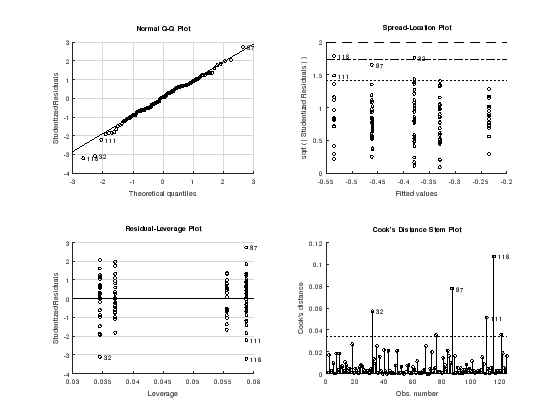

In [96]:
mdl = bootlm (outcomes_diff(:,1), {mutation_diff})

In [97]:
mdl

mdl =

  scalar structure containing the fields:

    method = Wild bootstrap-t
    name =
    {
      [1,1] = (Intercept)
      [1,2] = X1_1
      [1,3] = X1_2
      [1,4] = X1_3
      [1,5] = X1_4
      [1,6] = X1_5
    }

    estimate =

      -0.234719
      -0.144479
      -0.095516
      -0.227388
      -0.225668
      -0.300110

    CI_lower =

      -0.4616
      -0.4452
      -0.3729
      -0.5714
      -0.4906
      -0.6789

    CI_upper =

      -7.8845e-03
       1.5625e-01
       1.8186e-01
       1.1665e-01
       3.9261e-02
       7.8685e-02

    pval =

       0.043801
       0.326421
       0.485313
       0.187329
       0.090843
       0.116679

    fpr =

       0.2714
       0.4983
       0.5000
       0.4603
       0.3720
       0.4052

    N = 125
    prior = [](0x0)
    levels =
    {
      [1,1] =
      {
        [1,1] = WT
        [2,1] = K669N
        [3,1] = L812M
        [4,1] = C436R
        [5,1] = T531M
        [6,1] = R518H
      }

    }

    contrasts

In [98]:
animal_raw  = xlsread ('../data/n2a_mutant.xlsx', 'n2a_mutant', 'F2:F251');
animal_diff = animal_raw(plus_idx);

fprintf ('Unique animals: %d\n', numel (unique (animal_diff)))
disp (unique (animal_diff)')

Unique animals: 6
   1   2   3   4   5   6


In [99]:
contrast_S1 = [
  -5/6,    0,    0,    0,    0;  # WT 
  1/6,  3/5,    0,    0, -1/2;  # K669N
  1/6,  3/5,    0,    0,  1/2;  # L812M 
  1/6, -2/5, -1/3, -1/2,    0;  # C436R 
  1/6, -2/5, -1/3,  1/2,    0;  # T531M
  1/6, -2/5,  2/3,    0,    0;  # R518H
 
 
];

disp (contrast_S1)

  -0.8333        0        0        0        0
   0.1667   0.6000        0        0  -0.5000
   0.1667   0.6000        0        0   0.5000
   0.1667  -0.4000  -0.3333  -0.5000        0
   0.1667  -0.4000  -0.3333   0.5000        0
   0.1667  -0.4000   0.6667        0        0


ans = outcome 1
  -4.0025e-01
  -1.9863e-01
   1.3106e-01
  -7.3582e-02
   1.7201e-03
   4.8963e-02
ans = outcome 2
   0.445918
   0.564701
  -0.373498
  -0.038258
   0.059422
   0.033177
ans = outcome 3
   6.4011e-04
   3.2958e-01
  -2.5166e-01
  -2.9384e-01
   8.8815e-02
  -9.5383e-02
ans = outcome 4
   0.6030
   0.5656
  -0.3278
  -0.1500
   0.2349
   0.1873
ans = outcome 5
   0.5701
   0.5370
  -0.3261
  -0.1133
   0.2119
   0.1951
ans = outcome 6
  -0.085015
   0.031248
  -0.312311
  -0.068755
  -0.047216
  -0.014442
ans = outcome 7
   0.042574
  -0.102055
   0.332681
   0.139245
   0.049939
   0.162292
ans = outcome 8
  -0.048451
  -0.079303
  -0.062078
  -0.051489
   0.081850
   0.073946
ans = outcome 9
  -2.1102e-03
   8.0063e-03
   9.2337e-02
   5.9541e-02
  -1.3770e-01
   1.5704e-01
ans = outcome 10
  -0.049978
   0.023733
   0.171012
   0.079266
  -0.127928
  -0.027321
ans = outcome 11
  -2.8881e-02
  -9.8950e-03
   1.2309e-01
   1.0452e-01
  -8.5228e-02
   3.0183e-03


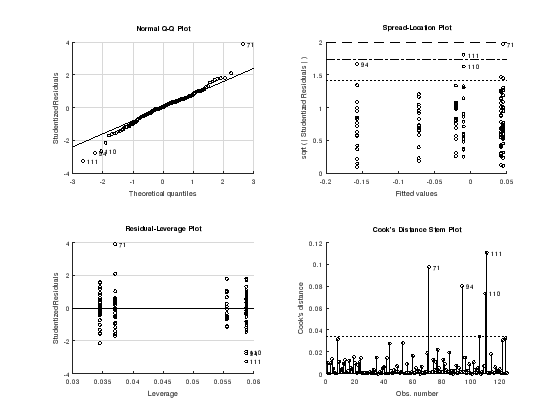

In [100]:
for i = 1:size (outcomes_diff, 2)
  MAT_T = bootlm (outcomes_diff(:,i), {mutation_diff}, ...
                  'model', 'linear', 'display', 'on', ...
                  'contrasts', {contrast_S1}, 'nboot', 0); 
  sprintf('outcome %d', i) 
  disp(MAT_T.b)
  print (sprintf ('../output/GRIN2A_outcome%d.png', i), '-dpng', '-r300')
end

In [101]:
Deff = 1

Deff = 1


In [102]:
MAT = bootlm (outcomes_diff(:,1), {mutation_diff}, ...
              'model', 'linear', 'display', 'off', ...
              'contrasts', {contrast_S1}, 'nboot', 0, 'dim', 1);
MAT.C

MAT = bootlm (outcomes_diff(:,1), {mutation_diff}, ...
              'model', 'linear', 'display', 'off', ...
              'contrasts', MAT.C, 'nboot', 0, 'dim', 1);

disp (MAT.X)

ans =
{
  [1,1] =

    -0.8333        0        0        0        0
     0.1667   0.6000        0        0  -0.5000
     0.1667   0.6000        0        0   0.5000
     0.1667  -0.4000  -0.3333  -0.5000        0
     0.1667  -0.4000  -0.3333   0.5000        0
     0.1667  -0.4000   0.6667        0        0

}

   1.0000  -0.8333        0        0        0        0
   1.0000  -0.8333        0        0        0        0
   1.0000  -0.8333        0        0        0        0
   1.0000  -0.8333        0        0        0        0
   1.0000  -0.8333        0        0        0        0
   1.0000  -0.8333        0        0        0        0
   1.0000  -0.8333        0        0        0        0
   1.0000  -0.8333        0        0        0        0
   1.0000  -0.8333        0        0        0        0
   1.0000  -0.8333        0        0        0        0
   1.0000  -0.8333        0        0        0        0
   1.0000  -0.8333        0        0        0        0
   1.0000  -0.8333        0  


 Empirical Bayes Ridge Regression (.632 Bootstrap Tuning) - Summary
 *******************************************************************************

 Number of predictors (p): 5

 Number of outcomes (q): 11

 Sample size: 125

 Design effect (Deff): 1

 Bootstrap resamples (nboot): 1999

 Minimized .632 bootstrap prediction error: 10.0174

 Predicted R-squared: 0.089 (8.9%)

 Bootstrap optimized ridge tuning constant (lambda): 6.17156

 Effective residual degrees of freedom (df_lambda): 121.

 Residual variances (range): [0.0801, 0.395]

 Inferential degrees of freedom (df_t): 121.
 Used for credible intervals and Bayes factors below.

 95% credible intervals for correlations between outcomes:
 (Prior on Fisher's z is flat/improper)

 Outcome J     Outcome I     correlation   CI_lower      CI_upper     
 1             2             -0.04365      -0.2218       +0.1373  
 1             3             +0.7211       +0.6220       +0.7976  
 1             4             +0.06960      -0.111

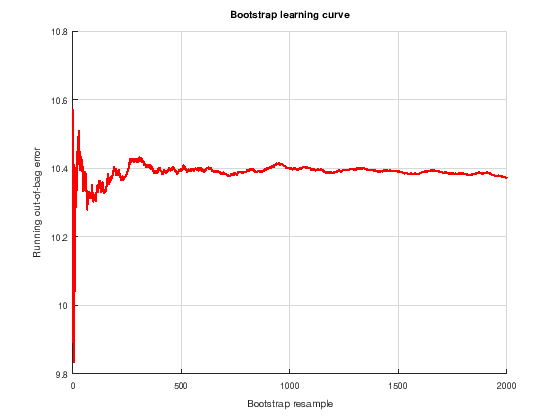

In [103]:
tic
bootridge (outcomes_diff, MAT.X, '*', 1999, 0.05, [], Deff);
toc
ridge_coeff = ans;

In [104]:
disp (ridge_coeff.stability * 100)

 Columns 1 through 8:

      NaN      NaN      NaN      NaN      NaN      NaN      NaN      NaN
   95.125   99.975   97.275   99.975   99.975   57.825   85.975   70.975
   91.525   99.975   97.675   99.975   99.975   99.775   99.975   72.625
   66.975   65.875   90.675   96.525   95.225   64.725   88.025   61.575
   51.975   68.425   67.725   97.875   97.925   61.175   67.375   67.025
   64.075   64.775   73.825   99.275   99.875   53.475   86.025   68.225

 Columns 9 through 11:

      NaN      NaN      NaN
   52.775   59.325   54.275
   88.175   97.925   96.875
   65.025   71.425   82.325
   85.675   84.425   80.675
   95.275   60.325   49.825


In [105]:
ridge_coeff.BF10

ans =

 Columns 1 through 6:

          NaN          NaN          NaN          NaN          NaN          NaN
   1.2760e+00   5.2389e+04   2.2739e+00   1.3159e+06   9.4639e+06   5.4095e-01
   8.9492e-01   8.2775e+03   2.2262e+00   8.6238e+03   9.9694e+04   7.9894e+00
   6.4518e-01   6.1819e-01   1.3271e+00   1.3289e+00   1.0714e+00   6.2363e-01
   6.4859e-01   6.9229e-01   6.8157e-01   2.4275e+00   2.5686e+00   6.5873e-01
   5.8050e-01   5.7749e-01   6.1814e-01   2.9204e+00   5.5268e+00   5.5454e-01

 Columns 7 through 11:

          NaN          NaN          NaN          NaN          NaN
   6.7662e-01   5.9572e-01   5.3762e-01   5.4777e-01   5.3746e-01
   9.4430e+01   4.9398e-01   6.9771e-01   2.1759e+00   1.8744e+00
   8.3265e-01   6.1108e-01   6.3570e-01   6.6793e-01   8.5212e-01
   6.6783e-01   6.8096e-01   8.2830e-01   7.9661e-01   7.6222e-01
   1.0001e+00   5.9919e-01   1.0286e+00   5.6459e-01   5.5347e-01



In [106]:
outcome_names = {'peakNMDA','decayNMDA','chargeNMDA','dt50NMDA','fwhmNMDA', ...
                 'peakAMPA','decayAMPA','chargeAMPA','riseAMPA','dt50AMPA','fwhmAMPA'};

fprintf ('DEFF per outcome (animal-level clustering):\n')
DEFF_per_outcome = zeros (1, 11);

for i = 1:11
  [~, BS_clust] = bootlm (outcomes_diff(:,i), {mutation_diff}, ...
                           'clustid', animal_diff, 'method', 'bayes', 'prior', 'auto', ...
                           'display', 'off', 'contrasts', 'treatment', 'seed', 1);
  [~, BS_iid]   = bootlm (outcomes_diff(:,i), {mutation_diff}, ...
                           'method', 'bayes', 'display', 'off', ...
                           'contrasts', 'treatment', 'seed', 1);
  DEFF_per_outcome(i) = mean (deffcalc (BS_clust, BS_iid));
  fprintf ('  %-12s: %.3f\n', outcome_names{i}, DEFF_per_outcome(i));
end

Deff = mean (DEFF_per_outcome);
fprintf ('\nMean DEFF used in bootridge: %.3f\n', Deff)

DEFF per outcome (animal-level clustering):
  peakNMDA    : 3.781
  decayNMDA   : 4.109
  chargeNMDA  : 3.181
  dt50NMDA    : 6.915
  fwhmNMDA    : 7.083
  peakAMPA    : 5.095
  decayAMPA   : 4.065
  chargeAMPA  : 5.866
  riseAMPA    : 1.453
  dt50AMPA    : 3.241
  fwhmAMPA    : 3.709

Mean DEFF used in bootridge: 4.409


In [107]:
Deff = mean (DEFF_per_outcome);
Deff

Deff = 4.4087


In [108]:
RTAB = ridge_coeff.RTAB;
disp (min (RTAB(:,3)));
disp (max (RTAB(:,3)));

-0.1744
0.9848



 Empirical Bayes Ridge Regression (.632 Bootstrap Tuning) - Summary
 *******************************************************************************

 Number of predictors (p): 5

 Number of outcomes (q): 11

 Sample size: 125

 Design effect (Deff): 4.41

 Bootstrap resamples (nboot): 1999

 Minimized .632 bootstrap prediction error: 10.0174

 Predicted R-squared: 0.089 (8.9%)

 Bootstrap optimized ridge tuning constant (lambda, Deff-adjusted): 1.39986

 Effective residual degrees of freedom (df_lambda): 119.

 Residual variances (range, Deff-inflated):  [0.335, 1.74]

 Inferential degrees of freedom (df_t, Deff-adjusted): 22.8
 Used for credible intervals and Bayes factors below.

 95% credible intervals for correlations between outcomes:
 (Prior on Fisher's z is flat/improper)

 Outcome J     Outcome I     correlation   CI_lower      CI_upper     
 1             2             -0.03627      -0.4540       +0.3945  
 1             3             +0.7268       +0.4370       +0.8799  
 1

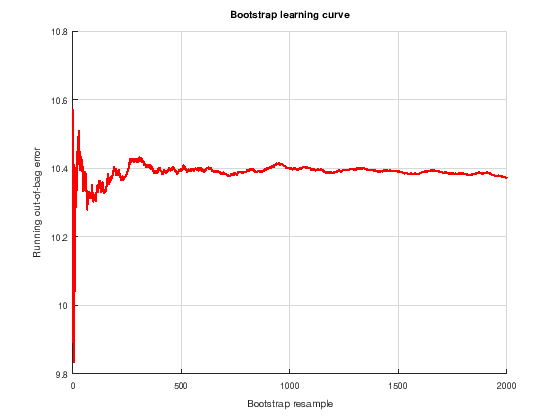

In [109]:
tic
bootridge (outcomes_diff, MAT.X, '*', 1999, 0.05, [], Deff);
toc
ridge_coeff = ans;


 Empirical Bayes Ridge Regression (.632 Bootstrap Tuning) - Summary
 *******************************************************************************

 Number of predictors (p): 5

 Number of outcomes (q): 11

 Sample size: 125

 Design effect (Deff): 4.41

 Bootstrap resamples (nboot): 1999

 Minimized .632 bootstrap prediction error: 10.0174

 Predicted R-squared: 0.089 (8.9%)

 Bootstrap optimized ridge tuning constant (lambda, Deff-adjusted): 1.39986

 Effective residual degrees of freedom (df_lambda): 119.

 Residual variances (range, Deff-inflated):  [0.335, 1.74]

 Inferential degrees of freedom (df_t, Deff-adjusted): 22.8
 Used for credible intervals and Bayes factors below.

 95% credible intervals for correlations between outcomes:
 (Prior on Fisher's z is flat/improper)

 Outcome J     Outcome I     correlation   CI_lower      CI_upper     
 1             2             -0.03627      -0.4540       +0.3945  
 1             3             +0.7268       +0.4370       +0.8799  
 1

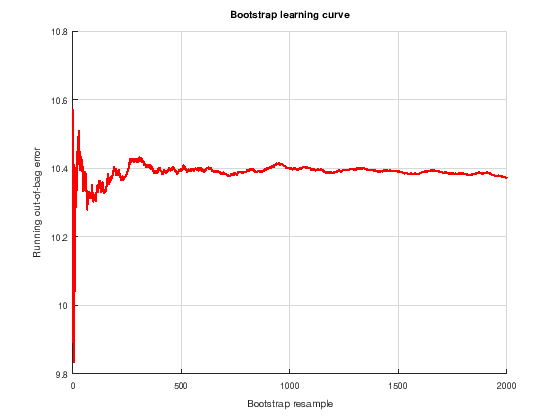

In [110]:
tic
bootridge (outcomes_diff, MAT.X, '*', 1999, 0.05, MAT.L, Deff);
toc
ridge_emm = ans;

In [111]:
unpen_emm = zeros (6, 11);
for i = 1:11
  tmp = bootlm (outcomes_diff(:,i), {mutation_diff}, 'contrasts', MAT.C, ...
                'dim', 1, 'nboot', 1999, 'display', 'off');
  unpen_emm(:,i) = tmp.estimate;
end

pen_emm = ridge_emm.estimate;

mut_levels = unique (mutation_diff, 'stable');
wt_row     = find (strcmp (mut_levels, 'WT'));   # = 1

fprintf ('=== ESTIMATED MARGINAL MEANS AS %% OF WT ===\n')
fprintf ('(penalised = ridge, unpenalised = OLS bootlm)\n\n')

for o = 1:11
  fprintf ('--- %s ---\n', outcome_names{o})
  fprintf ('%-8s  %16s  %16s\n', 'Mutation', 'Penalised (%WT)', 'Unpenalised (%WT)')
  fprintf ('%s\n', repmat ('-', 1, 44))
  for r = 1:numel (mut_levels)
    pen_pct   = exp (pen_emm(r,o)   - pen_emm(wt_row,o))   * 100;
    unpen_pct = exp (unpen_emm(r,o) - unpen_emm(wt_row,o)) * 100;
    fprintf ('%-8s  %14.1f%%  %14.1f%%\n', mut_levels{r}, pen_pct, unpen_pct);
  end
  fprintf ('\n')
end

=== ESTIMATED MARGINAL MEANS AS % OF WT ===
(penalised = ridge, unpenalised = OLS bootlm)

--- peakNMDA ---
Mutation   Penalised (%WT)  Unpenalised (%WT)
--------------------------------------------
WT                 100.0%           100.0%
K669N               87.9%            86.5%
L812M               91.8%            90.9%
C436R               81.1%            79.7%
T531M               81.2%            79.8%
R518H               76.0%            74.1%

--- decayNMDA ---
Mutation   Penalised (%WT)  Unpenalised (%WT)
--------------------------------------------
WT                 100.0%           100.0%
K669N              133.5%           138.3%
L812M              137.6%           142.9%
C436R              190.0%           200.8%
T531M              199.9%           213.1%
R518H              188.4%           199.1%

--- chargeNMDA ---
Mutation   Penalised (%WT)  Unpenalised (%WT)
--------------------------------------------
WT                 100.0%           100.0%
K669N              12

In [112]:
contrast_names = {'A: WT vs Mut', 'B: LOF vs GOF', 'C: LOF2 vs LOF1', 'D: LOF2', 'E: GOF1'};
outcome_names  = {'peakNMDA','decayNMDA','chargeNMDA','dt50NMDA','fwhmNMDA', ...
                  'peakAMPA','decayAMPA','chargeAMPA','riseAMPA','dt50AMPA','fwhmAMPA'};

fprintf ('\n%s\n', repmat('=', 1, 70))
fprintf ('RESULTS SUMMARY\n')
fprintf ('%s\n\n', repmat('=', 1, 70))

for c = 1:5
  fprintf ('Contrast %s\n', contrast_names{c})
  fprintf ('%-14s  %8s  %10s  %8s\n', 'Outcome', 'Coef', 'BF10', 'SS%')
  fprintf ('%s\n', repmat('-', 1, 46))
  for o = 1:11
    coef = ridge_coeff.coefficient(c+1, o); 
    bf   = ridge_coeff.BF10(c+1, o);
    ss   = ridge_coeff.stability(c+1, o) * 100;
    flag = '';
    if bf > 10 && ss > 97.5;  flag = '***'; end
    if bf > 3  && ss > 97.5 && strcmp(flag,''); flag = '**'; end
    if ss > 97.5 && strcmp(flag,''); flag = '*ss'; end
    fprintf ('%-14s  %8.3f  %10.1f  %7.1f%%  %s\n', ...
             outcome_names{o}, coef, bf, ss, flag)
  end
  fprintf ('\n')
end
fprintf ('*** CI + BF + SS all clear | ** BF + SS | *ss SS only\n')


RESULTS SUMMARY

Contrast A: WT vs Mut
Outcome             Coef        BF10       SS%
----------------------------------------------
peakNMDA          -0.181         0.4     78.5%  
decayNMDA          0.515         9.1     95.1%  
chargeNMDA         0.301         0.5     82.0%  
dt50NMDA           0.516        24.0     95.1%  
fwhmNMDA           0.490        43.5     95.1%  
peakAMPA           0.027         0.3     53.7%  
decayAMPA         -0.092         0.3     69.6%  
chargeAMPA        -0.073         0.3     60.4%  
riseAMPA           0.008         0.3     51.3%  
dt50AMPA           0.023         0.3     54.5%  
fwhmAMPA          -0.008         0.3     52.0%  

Contrast B: LOF vs GOF
Outcome             Coef        BF10       SS%
----------------------------------------------
peakNMDA           0.123         0.3     74.4%  
decayNMDA         -0.352         3.6     95.1%  
chargeNMDA        -0.237         0.4     82.8%  
dt50NMDA          -0.309         3.9     95.1%  
fwhmNMDA     

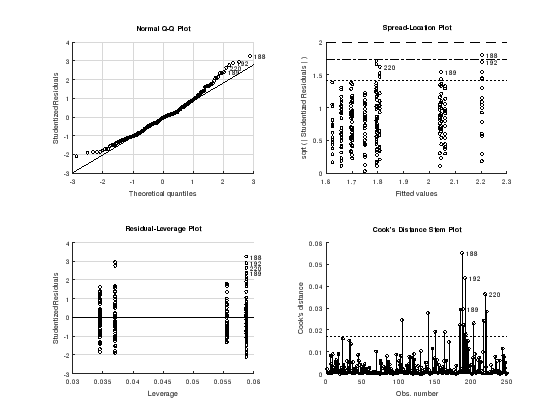

In [113]:
for i = 1:11
  MAT_int = bootlm (outcomes_log(:,i), {mutation, transfection}, ...
                    'model', 'full', 'display', 'on', ...
                    'contrasts', {contrast_S1, 'treatment'}, 'nboot', 0);
  print (sprintf ('../output/GRIN2A_interaction_outcome%d.png', i), '-dpng', '-r300')
end

In [114]:
MAT_int = bootlm (outcomes_log(:,1), {mutation, transfection}, ...
                  'model', 'full', 'display', 'off', ...
                  'contrasts', {contrast_S1, 'treatment'}, 'nboot', 0);

size (MAT_int.X)

ans =

   250    12



In [115]:
[~, BS_int_clust] = bootlm (outcomes_log(:,1), {mutation, transfection}, ...
                             'model', 'full', 'clustid', animal_raw, ...
                             'method', 'bayes', 'prior', 'auto', ...
                             'display', 'off', 'contrasts', {contrast_S1, 'treatment'}, 'seed', 1);
[~, BS_int_iid]   = bootlm (outcomes_log(:,1), {mutation, transfection}, ...
                             'model', 'full', 'method', 'bayes', 'display', 'off', ...
                             'contrasts', {contrast_S1, 'treatment'}, 'seed', 1);

Deff_int = mean (deffcalc (BS_int_clust, BS_int_iid));
fprintf ('Interaction model DEFF: %.3f\n', Deff_int)

Interaction model DEFF: 47.219


In [ ]:
tic
bootridge (outcomes_log, MAT_int.X, '*', 1999, 0.05, [], Deff_int);
toc
ridge_int = ans;

In [91]:
fprintf ('Interaction model (rows 8-12 = mutation x transfection):\n')
disp (ridge_int.coefficient(8:12, :))

fprintf ('\nDifferences model (rows 2-6 = mutation contrasts):\n')
disp (ridge_coeff.coefficient(2:6, :))